Data Loading and Preprocessing


We will use the Hugging Face Amazon Polarity review dataset for GRU based sentiment analysis.


In [ ]:
!uv pip install datasets matplotlib


In [ ]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from datasets import load_dataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.utils.data import DataLoader, Dataset


In [8]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MAX_VOCAB = 20000
MAX_LEN = 400
BATCH_SIZE = 64
EMBED_DIM = 128
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.3

print(f"Device: {DEVICE}")


Device: cuda


In [9]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    return re.findall(r"\b\w+\b", text)


def load_amazon_reviews():
    print("Loading Amazon Polarity dataset (subsampled)...")
    dataset = load_dataset("amazon_polarity")

    train_split = dataset["train"].shuffle(seed=42).select(range(25000))
    test_split = dataset["test"].shuffle(seed=42).select(range(25000))

    train_texts = [
        f"{t} {c}".strip()
        for t, c in zip(train_split["title"], train_split["content"])
    ]
    train_labels = train_split["label"]

    test_texts = [
        f"{t} {c}".strip()
        for t, c in zip(test_split["title"], test_split["content"])
    ]
    test_labels = test_split["label"]

    return train_texts, train_labels, test_texts, test_labels


In [ ]:
train_texts, train_labels, test_texts, test_labels = load_amazon_reviews()
print(f"Train samples: {len(train_texts)}")
print(f"Test samples: {len(test_texts)}")
print(train_texts[0][:500])


In [10]:
def build_vocab(texts, max_vocab):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    word2idx = {"<PAD>": 0, "<UNK>": 1}
    for word, _ in counter.most_common(max_vocab - 2):
        word2idx[word] = len(word2idx)
    return word2idx


def encode(text, word2idx, max_len=MAX_LEN):
    tokens = tokenize(text)[:max_len]
    return [word2idx.get(token, word2idx["<UNK>"]) for token in tokens]


In [11]:
word2idx = build_vocab(train_texts, MAX_VOCAB)
vocab_size = len(word2idx)
print(f"Vocab size: {vocab_size}")


Vocab size: 20000


We use token indexing, sequence length truncation, and dynamic padding to construct minibatches for the GRU model.


In [12]:
class AmazonReviewDataset(Dataset):
    def __init__(self, texts, labels, word2idx):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = encode(self.texts[idx], self.word2idx)
        if not encoded:
            encoded = [self.word2idx["<UNK>"]]
        return encoded, self.labels[idx]


def collate_fn(batch):
    sequences = [torch.tensor(item[0], dtype=torch.long) for item in batch]
    lengths = torch.tensor([len(sequence) for sequence in sequences], dtype=torch.long)
    labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
    padded = pad_sequence(sequences, batch_first=True, padding_value=0)
    return padded, lengths, labels


In [13]:
train_ds = AmazonReviewDataset(train_texts, train_labels, word2idx)
test_ds = AmazonReviewDataset(test_texts, test_labels, word2idx)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    pin_memory=True,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    collate_fn=collate_fn,
    pin_memory=True,
)


Model training


In [14]:
class SentimentGRU(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        num_classes=2,
        dropout=DROPOUT,
    ):
        super().__init__()
        gru_dropout = dropout if num_layers > 1 else 0.0
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=gru_dropout,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.gru(packed)
        last_hidden = hidden[-1]
        return self.fc(self.dropout(last_hidden))


Training


In [15]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, lengths, y in loader:
        x, lengths, y = x.to(DEVICE), lengths.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x, lengths)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for x, lengths, y in loader:
        x, lengths, y = x.to(DEVICE), lengths.to(DEVICE), y.to(DEVICE)
        logits = model(x, lengths)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def predict_text(model, text, word2idx):
    model.eval()
    ids = encode(text, word2idx)
    if not ids:
        ids = [word2idx["<UNK>"]]
    x = torch.tensor([ids], dtype=torch.long).to(DEVICE)
    lengths = torch.tensor([len(ids)], dtype=torch.long).to(DEVICE)
    logits = model(x, lengths)
    return logits.argmax(dim=1).item()


In [17]:
model = SentimentGRU(vocab_size).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 3
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)
    print(
        f"Epoch {epoch}/{EPOCHS}  "
        f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  "
        f"test_loss={test_loss:.4f}  test_acc={test_acc:.4f}"
    )


Epoch 1/3  train_loss=0.5322  train_acc=0.7328  test_loss=0.4015  test_acc=0.8261
Epoch 2/3  train_loss=0.3168  train_acc=0.8678  test_loss=0.2827  test_acc=0.8830
Epoch 3/3  train_loss=0.2135  train_acc=0.9154  test_loss=0.2635  test_acc=0.8910


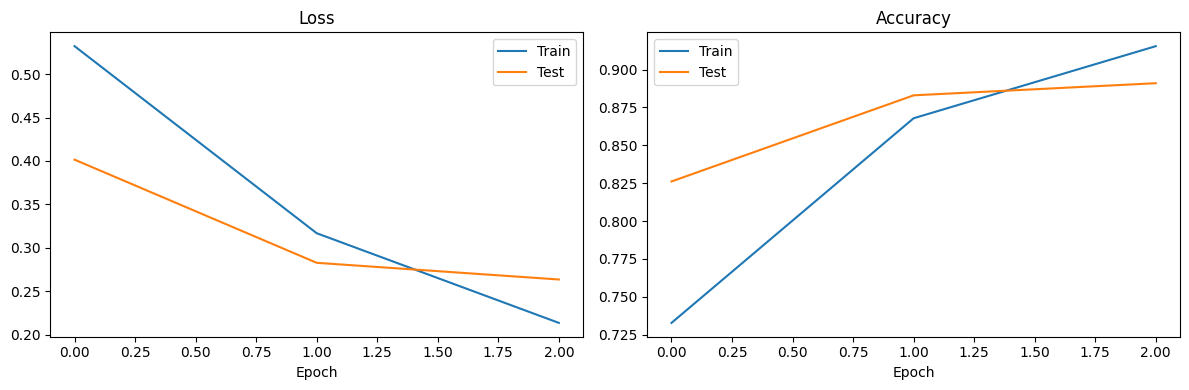

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["test_loss"], label="Test")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["test_acc"], label="Test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


In [19]:
label_map = {0: "negative", 1: "positive"}
samples = test_texts[:10]
sample_labels = test_labels[:10]
predictions = [predict_text(model, text, word2idx) for text in samples]

print(f"Final Test Accuracy: {history['test_acc'][-1]:.4f}\n")
for i, (text, true_label, pred_label) in enumerate(
    zip(samples, sample_labels, predictions), start=1
):
    print(f"--- Sample {i} ---")
    print(f"Text: {text[:200]}...")
    print(f"True: {label_map[true_label]}  |  Predicted: {label_map[pred_label]}\n")


Final Test Accuracy: 0.8910

--- Sample 1 ---
Text: Damaged Product The product works fine. I ordered the more exprensive one after I read reviews from others on Amazon. My husband likes the presser. It does a good job pressing his pants. However, it w...
True: positive  |  Predicted: positive

--- Sample 2 ---
Text: A waste of time and money This book is so useless that I feel compelled to write a review to warn others to stay away from this book. A good tutorial should inspire the user on what he/she can do with...
True: negative  |  Predicted: negative

--- Sample 3 ---
Text: Scattered, Out-of-Date, The authors attempt an ambitious goal of covering many SOA topics - but their resulting text come across as scattered - vague - and lacking a coherent and practical application...
True: negative  |  Predicted: negative

--- Sample 4 ---
Text: Horrible Customer Service & Product I ordered this product and did recieve then a couple months later it broke. Now Ive done everything I was told 

GRU performs better than a simple RNN for sentiment analysis because its gates help preserve useful information across longer review sequences.
